How does activity vary between the different cerebral areas ?

In [2]:
import io
import numpy as np
import requests # HTTPS request API 

### What are we working with?
Let's have a look at the metadata file and the architecture of the downloaded sy5xt file, which has only 1 column: the spike times of these 734 neurons. Let's import the dataset and check if it's correctly loaded

In [16]:
r = requests.get('https://osf.io/sy5xt/download') 

if r.status_code != 200: 
    # 200 is the validation code that confirms that the request has been successful
    print('Download failed')
else:
    data = np.load(io.BytesIO(r.content), allow_pickle=True)  # pickle allows np.load to load complex data (several tables), essential here as all neurons have different numbers of spikes
    print("available keys:", data.files)
    
    spike_times = data['spike_times'] # technically useless because only one column

    # Description shows type and length(s) of the dataset
    print(f"Data type : {type(spike_times)}")
    print(f"Data col lengths : {len(spike_times)}")

    # Afficher la forme de chaque tableau de spikes
    print("\nData shape for the 5 first neurons :")
    for i in range(min(5, len(spike_times))):
        print(f"Neuron {i+1} : {spike_times[i].shape} (Spike number : {len(spike_times[i])})")

    print(f"Loaded table : {len(spike_times)} neurons")

available keys: ['spike_times']
Type de spike_times : <class 'numpy.ndarray'>
Nombre de neurones (longueur de spike_times) : 734

Forme des temps de spike pour les 5 premiers neurones :
Neurone 1 : (826,) (nombre de spikes : 826)
Neurone 2 : (2818,) (nombre de spikes : 2818)
Neurone 3 : (3953,) (nombre de spikes : 3953)
Neurone 4 : (646,) (nombre de spikes : 646)
Neurone 5 : (1115,) (nombre de spikes : 1115)
Loaded table : 734 neurons


Example with the first neuron, and plot of its first discharges

In [7]:
neuron_0 = spike_times[0] # Let's look at the first neuron's spike time
print(f"Number of spikes for this neuron : {len(neuron_0)}")
print(f"First discharge instants : {neuron_0[:10]}")

Number of spikes for this neuron : 826
First discharge instants : [  0.8149    14.822467  24.9646    25.1436    38.8709    50.8208
  54.806866  59.511833  80.47037  127.09637 ]


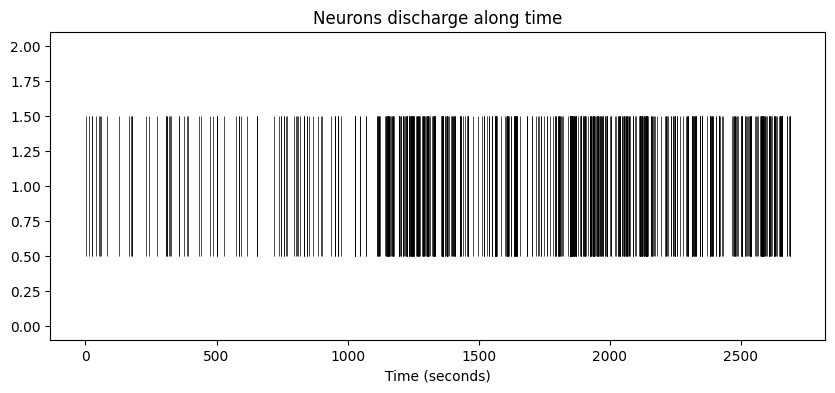

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.eventplot(spike_times[0], color='black', linewidths=0.5)
plt.xlabel("Time (seconds)")
plt.title("First euron discharge along time")
plt.show()

Test with the 20 first neurons

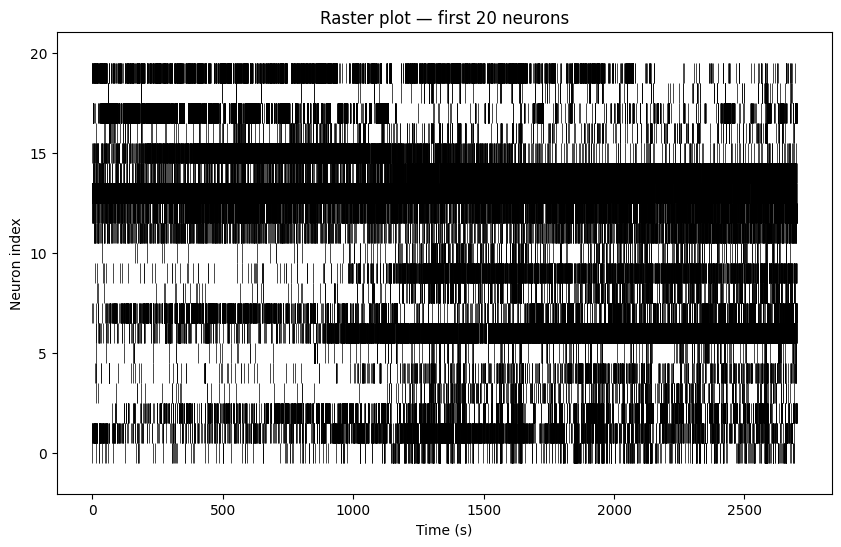

In [11]:
n_neurons_to_plot = 20 # Select the first 20 neurons to keep the plot readable

plt.figure(figsize=(10,6))
plt.eventplot(spike_times[:n_neurons_to_plot], color='black', linewidths=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Neuron index")
plt.title(f"Raster plot — first {n_neurons_to_plot} neurons")
plt.show()